In [1]:
# pyright: reportUnusedImport=false, reportMissingImports=false, reportMissingModuleSource=false
import pandas as pd
import numpy as np
import tensorflow as tf
import os
import seaborn as sb
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, Rescaling
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

2026-05-14 02:34:41.372255: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-14 02:34:42.063064: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-14 02:34:42.063128: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-14 02:34:42.066294: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-14 02:34:42.398188: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-14 02:34:42.403954: I tensorflow/core/platform/cpu_feature_guard.cc:182] This Tens

In [2]:
normal_cells=os.listdir('brain_tumor_dataset/no/')
tumor_cells=os.listdir('brain_tumor_dataset/yes/')

# total images in each folder

In [3]:
print('Number of normal cells: ',len(normal_cells))
print('Number of tumor cells: ',len(tumor_cells))

Number of normal cells:  98
Number of tumor cells:  157


In [4]:
TRAIN_DIR='brain_tumor_dataset'

# image resize 

In [5]:
# Instantiate the dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=(128, 128),
    batch_size=32,
    label_mode='binary',
    seed=100
)

# Check the type    
dataset_type = type(train_dataset)
print(f'train_dataset inherits from tf.data.Dataset: {issubclass(dataset_type, tf.data.Dataset)}')

Found 255 files belonging to 2 classes.
train_dataset inherits from tf.data.Dataset: True


In [6]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset='validation',
    image_size=(128, 128),
    batch_size=32,
    label_mode='binary',
    seed=100
)
dataset_type = type(train_dataset)
print(f'train_dataset inherits from tf.data.Dataset: {issubclass(dataset_type, tf.data.Dataset)}')

Found 255 files belonging to 2 classes.
Using 51 files for validation.
train_dataset inherits from tf.data.Dataset: True


# validating the image shapes

In [7]:
# check the image shape and labels
for images, labels in train_dataset.take(1):
    print(f'Image batch shape: {images.shape}')
    print(f'Label batch shape: {labels.shape}')

2026-05-14 02:35:05.216051: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 19926816 exceeds 10% of free system memory.


Image batch shape: (32, 128, 128, 3)
Label batch shape: (32, 1)


In [8]:
# genrate augmented images
data_augumentation=ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    vertical_flip=True,
    horizontal_flip=True
)

In [9]:
rescale=Rescaling(1./255)
train_dataset = train_dataset.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

# improving performance

In [10]:
train_dataset=(
    train_dataset.cache()
    .shuffle(100).
    prefetch(buffer_size=tf.data.AUTOTUNE)
)

In [11]:
val_ds=(
    val_ds.cache()
    .prefetch(buffer_size=tf.data.AUTOTUNE)
)

# defining early stop at 82 percent

In [12]:
class EarlyStopping(tf.keras.callbacks.Callback):
    def on_epoch_end(self,epoch,logs=None):
        if logs.get("accuracy")>0.82:
            print("\nReached 82% accuracy so cancelling training!")
            self.model.stop_training=True

In [13]:
model=Sequential([
    tf.keras.layers.Input(shape=(128,128,3)),
    Conv2D(16,3,activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(32,3,activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(64,3,activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128,3,activation='relu'),
    MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),
    Dense(256,activation='relu'),
    Dense(1,activation='sigmoid')


])

In [14]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 126, 126, 16)      448       
                                                                 
 max_pooling2d (MaxPooling2  (None, 63, 63, 16)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 61, 61, 32)        4640      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 30, 30, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 28, 28, 64)        18496     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 14, 14, 64)        0

In [15]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=['accuracy']
)

# using pre-build early stopping
using validation set also for fitting

In [16]:
history = model.fit(
    train_dataset,
    validation_data=val_ds,
    epochs=10,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',  
            patience=5,
            restore_best_weights=True
        )
    ]
    )

Epoch 1/10


2026-05-14 02:35:20.190179: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 19926816 exceeds 10% of free system memory.
2026-05-14 02:35:20.461932: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 32514048 exceeds 10% of free system memory.
2026-05-14 02:35:20.801827: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 24385536 exceeds 10% of free system memory.
2026-05-14 02:35:20.801944: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 24385536 exceeds 10% of free system memory.


8/8 [==============================] - 5s 406ms/step - loss: 0.7370 - accuracy: 0.6314 - val_loss: 0.6402 - val_accuracy: 0.6078
Epoch 2/10
8/8 [==============================] - 2s 309ms/step - loss: 0.6228 - accuracy: 0.6510 - val_loss: 0.5446 - val_accuracy: 0.8431
Epoch 3/10
8/8 [==============================] - 2s 296ms/step - loss: 0.5597 - accuracy: 0.7569 - val_loss: 0.4697 - val_accuracy: 0.8235
Epoch 4/10
8/8 [==============================] - 2s 283ms/step - loss: 0.5335 - accuracy: 0.7333 - val_loss: 0.4277 - val_accuracy: 0.8235
Epoch 5/10
8/8 [==============================] - 2s 279ms/step - loss: 0.4748 - accuracy: 0.7882 - val_loss: 0.3724 - val_accuracy: 0.8431
Epoch 6/10
8/8 [==============================] - 2s 299ms/step - loss: 0.4700 - accuracy: 0.8118 - val_loss: 0.3729 - val_accuracy: 0.8431
Epoch 7/10
8/8 [==============================] - 2s 281ms/step - loss: 0.4393 - accuracy: 0.8235 - val_loss: 0.3156 - val_accuracy: 0.9020
Epoch 8/10
8/8 [===============

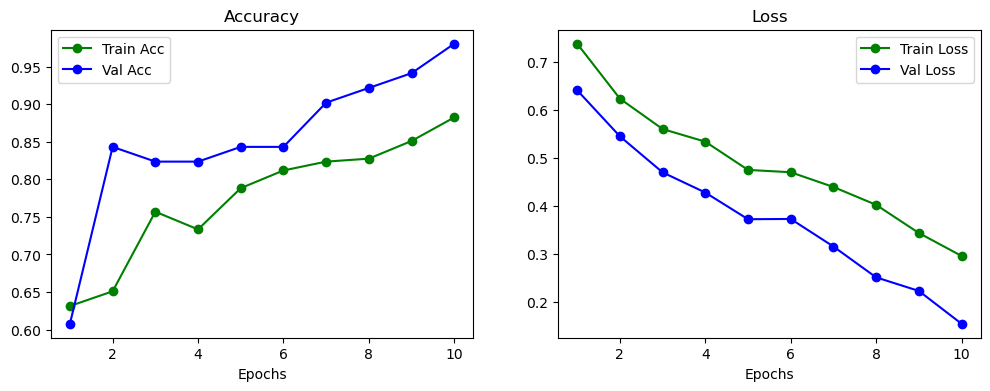

In [17]:

import matplotlib.pyplot as plt
try:
    h = history.history if hasattr(history, 'history') else history
    epochs = range(1, len(next(iter(h.values()))) + 1)
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    if 'accuracy' in h or 'acc' in h:
        acc = h.get('accuracy') or h.get('acc')
        plt.plot(epochs, acc, 'go-', label='Train Acc')
    if 'val_accuracy' in h or 'val_acc' in h:
        val_acc = h.get('val_accuracy') or h.get('val_acc')
        plt.plot(epochs, val_acc, 'bo-', label='Val Acc')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend()
    plt.subplot(1,2,2)
    if 'loss' in h:
        plt.plot(epochs, h['loss'], 'go-', label='Train Loss')
    if 'val_loss' in h:
        plt.plot(epochs, h['val_loss'], 'bo-', label='Val Loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()
    plt.show()
except Exception as e:
    print('Plot failed:', e)
    print('Ensure `history` is the return value from `model.fit(...)`')

In [18]:
Test_Dir="test_images"

In [19]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    Test_Dir,
    image_size=(128, 128),
    batch_size=32,
    label_mode='binary',
    seed=100
)

Found 255 files belonging to 2 classes.


In [20]:
model.evaluate(test_dataset)

8/8 [==============================] - 1s 53ms/step - loss: 17.1722 - accuracy: 0.9216


[17.17222785949707, 0.9215686321258545]

In [21]:
model.predict(test_dataset)

8/8 [==============================] - 1s 43ms/step


array([[1.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [0.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [0.0000000e+00],
       [0.0000000e+00],
       [5.3223716e-03],
       [1.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [0.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [0.0000000e+00],
       [1.0000000e+00],
       [0.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [0.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [0.0000000e+00],
       [1.0000000e+00],
       [1.000000

## Confusion Matrix

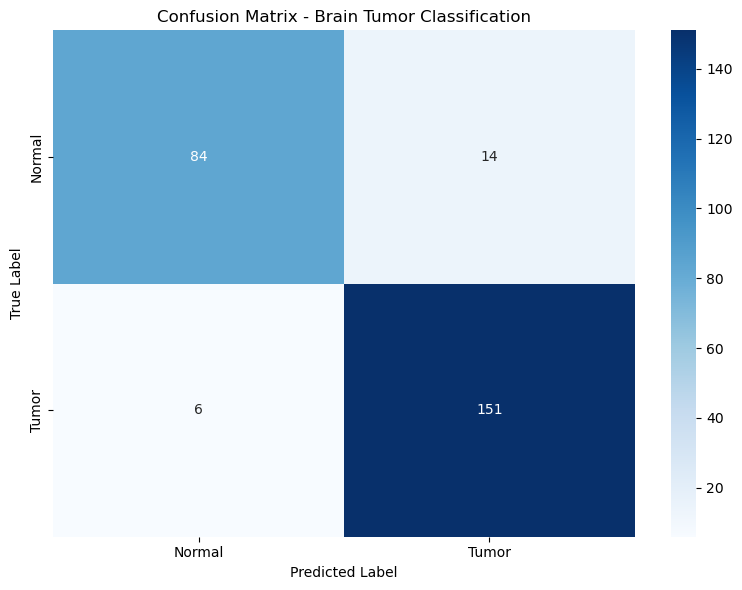

In [23]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions on test set
y_true = []
y_pred_prob = []

for images, labels in test_dataset:
    y_true.extend(labels.numpy())
    predictions = model.predict(images, verbose=0)
    y_pred_prob.extend(predictions.flatten())

y_true = np.array(y_true)
y_pred = (np.array(y_pred_prob) >= 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Tumor'],
            yticklabels=['Normal', 'Tumor'])
plt.title('Confusion Matrix - Brain Tumor Classification')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()


## Decision Boundary Visualization (2D Projection)



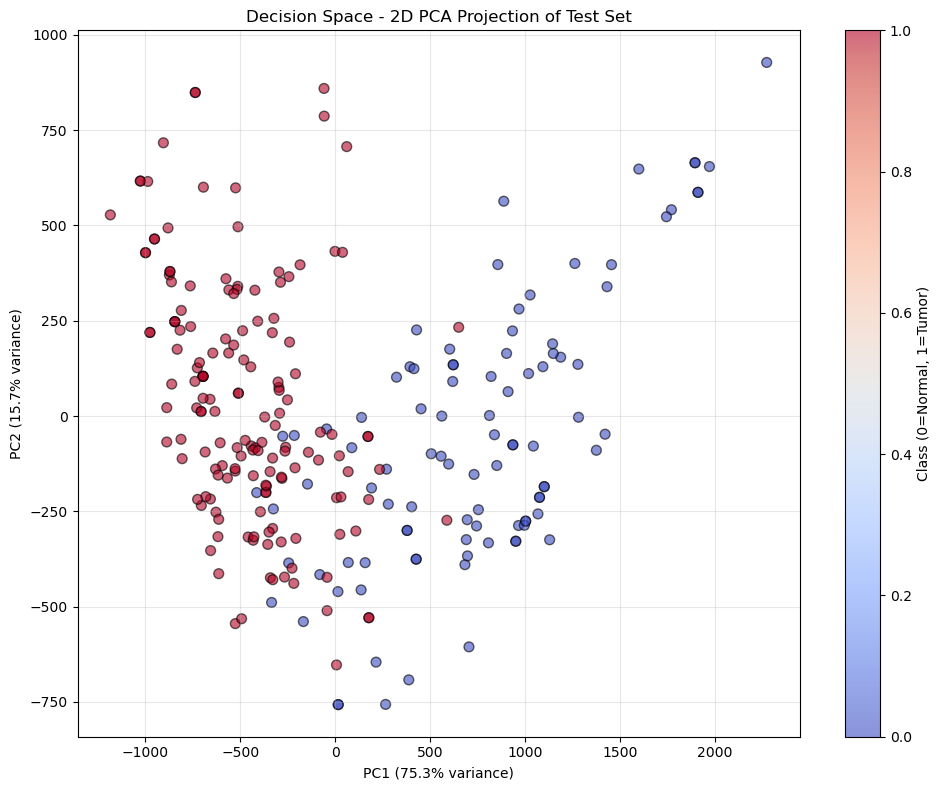

PCA explained variance: 90.9%


In [24]:
# Extract features from second-to-last layer and visualize decision boundary
from sklearn.decomposition import PCA

# Create a model that outputs features from before the final classification layer
feature_extractor = tf.keras.Model(
    inputs=model.input,
    outputs=model.layers[-2].output  # Get Dense(256) layer output
)

# Extract features and predictions
features_list = []
labels_list = []

for images, labels in test_dataset:
    features = feature_extractor.predict(images, verbose=0)
    features_list.append(features)
    labels_list.extend(labels.numpy())

features = np.vstack(features_list)
labels = np.array(labels_list)

# Reduce to 2D using PCA
pca = PCA(n_components=2)
features_2d = pca.fit_transform(features)

# Plot decision boundary and data points
plt.figure(figsize=(10, 8))
scatter = plt.scatter(features_2d[:, 0], features_2d[:, 1], 
                     c=labels, cmap='coolwarm', s=50, alpha=0.6, edgecolors='k')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('Decision Space - 2D PCA Projection of Test Set')
plt.colorbar(scatter, label='Class (0=Normal, 1=Tumor)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.1%}")

# upload images 

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import io
from PIL import Image


uploader = widgets.FileUpload(
    accept='image/*',   # Accept all image types
    multiple=False,     # Single file upload
    description='Upload Image',
    button_style='info' # Blue color
)
output = widgets.Output()

def on_predict_clicked(b):
    with output:
        clear_output()
        
        
        if not uploader.value:
            print(" Please upload an image first.")
            return
            
        print("Processing...")
        
        
        # Support both dict (new ipywidgets) and list/tuple formats
        if isinstance(uploader.value, dict):
            uploaded_file = next(iter(uploader.value.values()))
        else:
            uploaded_file = uploader.value[0]

        # filename may be at top-level or under metadata depending on widget/version
        filename = uploaded_file.get('name') or (uploaded_file.get('metadata') or {}).get('name', 'uploaded_image')
        content = uploaded_file.get('content') or uploaded_file.get('data')
        
        
        image = Image.open(io.BytesIO(content)).convert('RGB')
        display_img = image.copy()
        display_img.thumbnail((200, 200)) 
        
        
        image = image.resize((128, 128))
        image_array = np.array(image) / 255.0
        image_array = np.expand_dims(image_array, axis=0)

        
        prediction = model.predict(image_array, verbose=0)[0][0]
        label = 'Tumor' if prediction >= 0.5 else 'Normal'
        confidence = prediction if prediction >= 0.5 else 1 - prediction

        
        display(display_img)
        print(f'File: {filename}')
        print(f'Prediction: {label}')
        print(f'Confidence: {confidence:.2%}')


predict_btn = widgets.Button(
    description='Predict Tumor',
    button_style='success', 
    tooltip='Click to analyze the uploaded image'
)
predict_btn.on_click(on_predict_clicked)


print("--- Brain Tumor Classifier ---")
display(widgets.VBox([uploader, predict_btn, output]))


### wraping our model in .keras(.h5) to consume at backend fast api

In [ ]:
model.save('brain_tumor_classifier.keras')